# EDA y modelación no supervisada para priorización de manzanas con potencial de renovación urbana

Este notebook presenta el análisis exploratorio de datos (EDA) y la aplicación de técnicas de aprendizaje no supervisado para identificar tipologías urbanas y priorizar manzanas con potencial de renovación urbana dentro de las Actuaciones Estratégicas del POT de Bogotá.

## Estructura del análisis
1. Carga y revisión del dataset
2. Calidad de datos
3. Análisis normativo y filtro de exclusiones
4. Análisis exploratorio de variables urbanas
5. Normalización
6. PCA
7. Método del codo
8. K-Means
9. Interpretación de clusters
10. Análisis territorial por actuación estratégica
11. Exportación de resultados

LIBRERÍAS

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

CARGAR ARCHIVO

In [6]:
from google.colab import files
uploaded = files.upload()

Saving manzanas_final.xlsx to manzanas_final (1).xlsx


In [7]:
df = pd.read_excel("manzanas_final.xlsx")
df.head()

,objectid,man_codigo,actuacion_estrategica,ae_priorizada,cod_dane,area_manzana,densidad,viviendas,poblacion,dist_tm,...,viviendas_desocupadas,tiene_parque,tiene_equipa_pub,tiene_esp_pub,tiene_aim,plan_parcial_excluido,estado_pp,tiene_bic,sum_exclusiones,calificables
0,1,8544012,Lagos de Torca,0,1100110000000085330115,9850.528979,0.048472,190.0,492.0,211.750049,...,1.0,0.0,0.0,0.0,0.0,0.0,Ninguno,0.0,0.0,1.0
1,2,8519059,Nodo Toberin,0,1100110000000085190312,3952.997481,0.013165,20.0,52.0,826.160220,...,2.0,0.0,0.0,0.0,0.0,0.0,Ninguno,0.0,0.0,1.0
2,3,8516029,Nodo Toberin,0,1100110000000085160107,6712.437990,0.027434,50.0,184.0,773.151617,...,2.0,0.0,0.0,0.0,0.0,0.0,Ninguno,0.0,0.0,1.0
3,4,8516019,Nodo Toberin,0,1100110000000085160201,21563.511592,0.038000,325.0,822.0,567.918018,...,6.0,0.0,0.0,0.0,0.0,0.0,Ninguno,0.0,0.0,1.0
4,5,8501008,Nodo Toberin,0,1100110000000085010206,17517.294260,0.005901,47.0,100.0,238.909162,...,0.0,0.0,0.0,0.0,0.0,0.0,Ninguno,0.0,0.0,1.0


REVISIÓN BÁSICA DEL DATASET

## 1. Carga y estructura del dataset

En esta sección se revisa la estructura general del conjunto de datos, incluyendo número de observaciones, variables y tipos de datos.

In [8]:
df.isnull().sum()

,0
objectid,0
man_codigo,0
actuacion_estrategica,0
ae_priorizada,0
cod_dane,166
area_manzana,0
densidad,166
viviendas,166
poblacion,166
dist_tm,166


In [9]:
total_manzanas = len(df)
manzanas_con_nulos = df.isnull().any(axis=1).sum()
porcentaje_nulos = manzanas_con_nulos / total_manzanas * 100

print(f"Total de manzanas: {total_manzanas}")
print(f"Manzanas con al menos un valor nulo: {manzanas_con_nulos}")
print(f"Porcentaje de manzanas con nulos: {porcentaje_nulos:.2f}%")

Total de manzanas: 3400
Manzanas con al menos un valor nulo: 166
Porcentaje de manzanas con nulos: 4.88%


### Interpretación de valores faltantes

Los valores nulos identificados corresponden principalmente a manzanas que no presentaron correspondencia espacial en el cruce con información censal del DANE u otras variables derivadas. Estas observaciones se excluyen del análisis posterior para garantizar consistencia en los procesos de normalización, PCA y clustering.

In [11]:
df = df.dropna().copy()
print("Dimensiones después de eliminar nulos:", df.shape)

Dimensiones después de eliminar nulos: (3234, 25)


## 3. Cobertura de información censal

La variable `cantidad_encuestas` representa el número de observaciones censales asociadas a cada manzana. Aunque no se incorpora directamente al modelo de clustering, es útil para evaluar la cobertura y representatividad de la información derivada del cruce con el DANE.

In [12]:
df["cantidad_encuestas"].describe()

,cantidad_encuestas
count,3234.000000
mean,57.861163
std,68.015352
min,0.000000
25%,22.000000
50%,44.000000
75%,72.000000
max,1040.000000


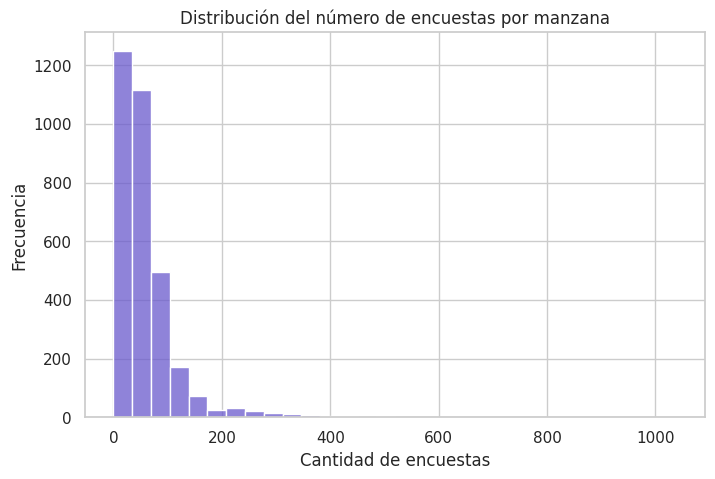

In [13]:
plt.figure(figsize=(8,5))
sns.histplot(df["cantidad_encuestas"], bins=30, color="slateblue")
plt.title("Distribución del número de encuestas por manzana")
plt.xlabel("Cantidad de encuestas")
plt.ylabel("Frecuencia")
plt.show()

### Interpretación de `cantidad_encuestas`

La distribución de `cantidad_encuestas` permite identificar la cobertura censal de las manzanas analizadas. Valores bajos pueden indicar menor soporte de información, mientras que valores altos reflejan mayor cantidad de observaciones asociadas a la manzana. Esta variable no se utiliza en el clustering, pero sí aporta contexto sobre la calidad de la información disponible.

ANALISIS NORMATIVO

## 4. Análisis normativo y filtro de exclusiones

Antes de la modelación se analizan las variables normativas, ya que estas permiten excluir manzanas que no pueden ser objeto de procesos de renovación urbana según el POT y otras restricciones urbanísticas.

In [15]:
df["calificables"].value_counts()

,count
calificables,
1.0,2228
0.0,1006


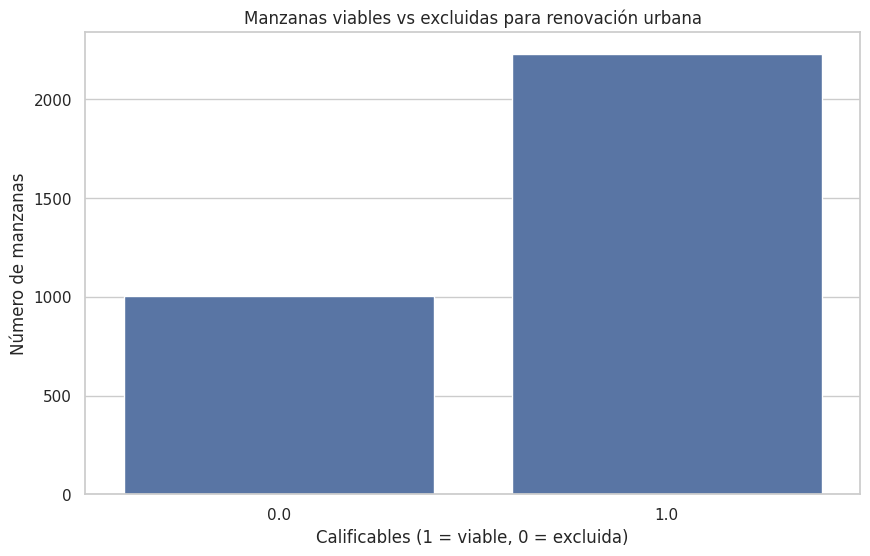

In [16]:
sns.countplot(x="calificables", data=df)
plt.title("Manzanas viables vs excluidas para renovación urbana")
plt.xlabel("Calificables (1 = viable, 0 = excluida)")
plt.ylabel("Número de manzanas")
plt.show()

In [17]:
cols_normativas = [
    "tiene_parque",
    "tiene_equipa_pub",
    "tiene_esp_pub",
    "tiene_aim",
    "plan_parcial_excluido",
    "tiene_bic"
]

df[cols_normativas].sum().sort_values(ascending=False)

,0
tiene_parque,441.0
tiene_aim,240.0
tiene_equipa_pub,202.0
tiene_bic,155.0
plan_parcial_excluido,105.0
tiene_esp_pub,25.0


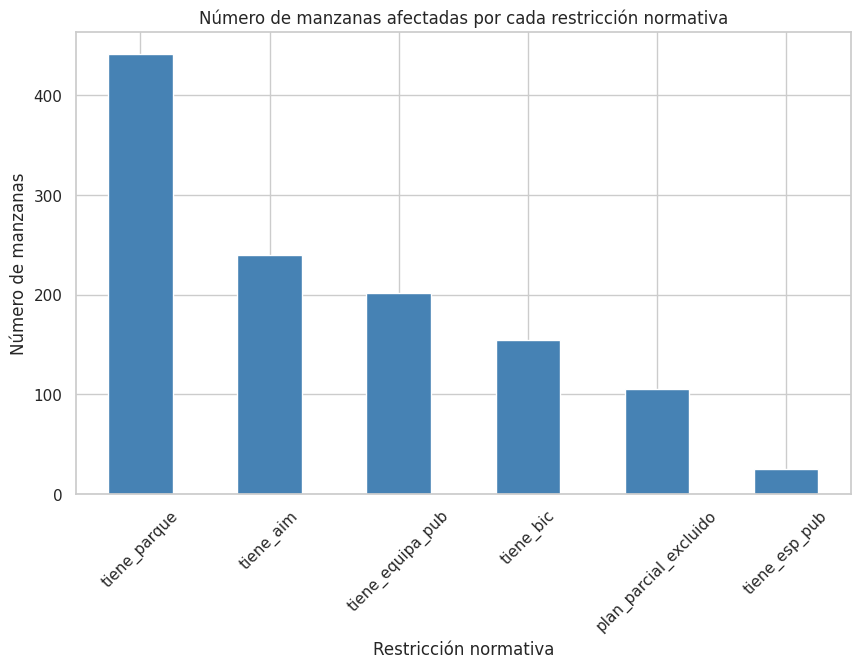

In [18]:
causas_exclusion = df[cols_normativas].sum().sort_values(ascending=False)

causas_exclusion.plot(kind="bar", color="steelblue")
plt.title("Número de manzanas afectadas por cada restricción normativa")
plt.xlabel("Restricción normativa")
plt.ylabel("Número de manzanas")
plt.xticks(rotation=45)
plt.show()

### Interpretación del análisis normativo

Las variables normativas no se incorporan directamente al modelo de clustering, pero sí son fundamentales para construir el filtro urbano previo. Estas variables permiten excluir manzanas que no pueden ser objeto de renovación urbana por restricciones como presencia de parques, equipamientos, espacio público, áreas de interés ambiental, planes parciales vigentes o bienes de interés cultural.

FILTRAR MANZANAS VIABLES

In [19]:
df_modelo = df[df["calificables"] == 1].copy()
print("Dimensiones del dataset para modelación:", df_modelo.shape)

Dimensiones del dataset para modelación: (2228, 25)


VARIABLES DEL MODELO

## 5. Selección de variables urbanas para análisis

Se utilizan variables urbanas y demográficas que permiten caracterizar intensidad urbana, accesibilidad, estructura física de la manzana y vacancia residencial.

In [20]:
variables = [
    "area_manzana",
    "densidad",
    "viviendas",
    "poblacion",
    "dist_tm",
    "mix_uso",
    "viviendas_desocupadas"
]

variables

['area_manzana',
 'densidad',
 'viviendas',
 'poblacion',
 'dist_tm',
 'mix_uso',
 'viviendas_desocupadas']

### Nota sobre la variable `mix_uso`

La variable `mix_uso` se construyó como la suma de unidades no residenciales con uso comercial e industrial. Por esta razón, no representa un índice clásico de mezcla de usos del suelo, sino un indicador proxy de actividad económica no residencial en la manzana.

Esta variable se incorpora al análisis con el fin de capturar la presencia de funciones económicas urbanas que pueden incidir en el potencial de transformación del territorio.

DESCRIPTIVOS URBANOS

In [21]:
df_modelo[variables].describe().round(3)

,area_manzana,densidad,viviendas,poblacion,dist_tm,mix_uso,viviendas_desocupadas
count,2228.000,2228.000,2228.000,2228.00,2228.000,2228.000,2228.000
mean,6443.119,0.045,48.119,135.73,459.182,6.403,2.089
std,16463.472,0.040,51.549,137.04,594.588,8.489,4.296
min,119.998,0.000,0.000,0.00,0.000,0.000,0.000
25%,2059.153,0.011,19.000,49.00,202.006,1.000,0.000
50%,3592.836,0.035,38.000,112.00,325.295,3.000,1.000
75%,6245.571,0.075,63.000,188.25,567.967,9.000,3.000
max,478727.446,0.198,901.000,2561.00,5172.947,62.000,95.000


HISTOGRAMAS

## 6. Distribución de variables urbanas

Se analiza la distribución de las variables urbanas mediante histogramas, con el fin de identificar sesgos, concentraciones y comportamientos extremos.

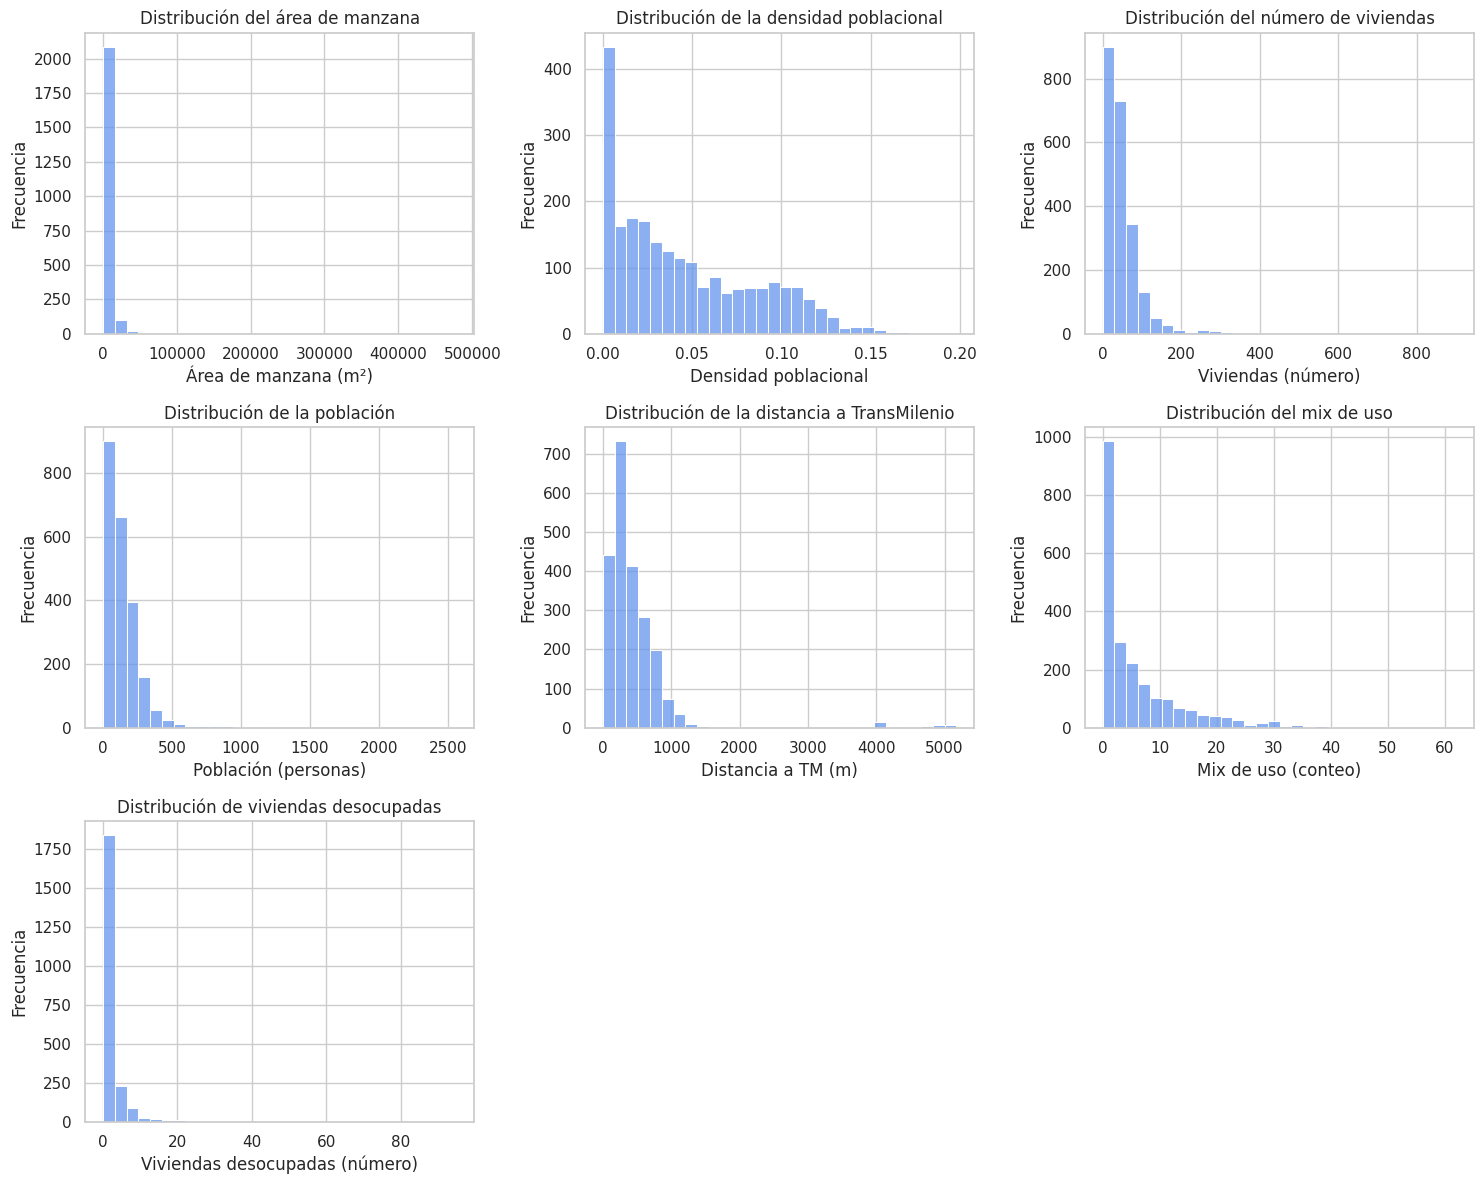

In [22]:
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

graficos = [
    ("area_manzana", "Distribución del área de manzana", "Área de manzana (m²)"),
    ("densidad", "Distribución de la densidad poblacional", "Densidad poblacional"),
    ("viviendas", "Distribución del número de viviendas", "Viviendas (número)"),
    ("poblacion", "Distribución de la población", "Población (personas)"),
    ("dist_tm", "Distribución de la distancia a TransMilenio", "Distancia a TM (m)"),
    ("mix_uso", "Distribución del mix de uso", "Mix de uso (conteo)"),
    ("viviendas_desocupadas", "Distribución de viviendas desocupadas", "Viviendas desocupadas (número)")
]

for i, (var, titulo, xlabel) in enumerate(graficos):
    sns.histplot(df_modelo[var], bins=30, ax=axes[i], color="cornflowerblue")
    axes[i].set_title(titulo)
    axes[i].set_xlabel(xlabel)
    axes[i].set_ylabel("Frecuencia")

for j in range(len(graficos), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

BOXPLOT

## 7. Detección de valores atípicos

Se usan diagramas de caja para identificar valores extremos y evaluar la dispersión de las variables urbanas.

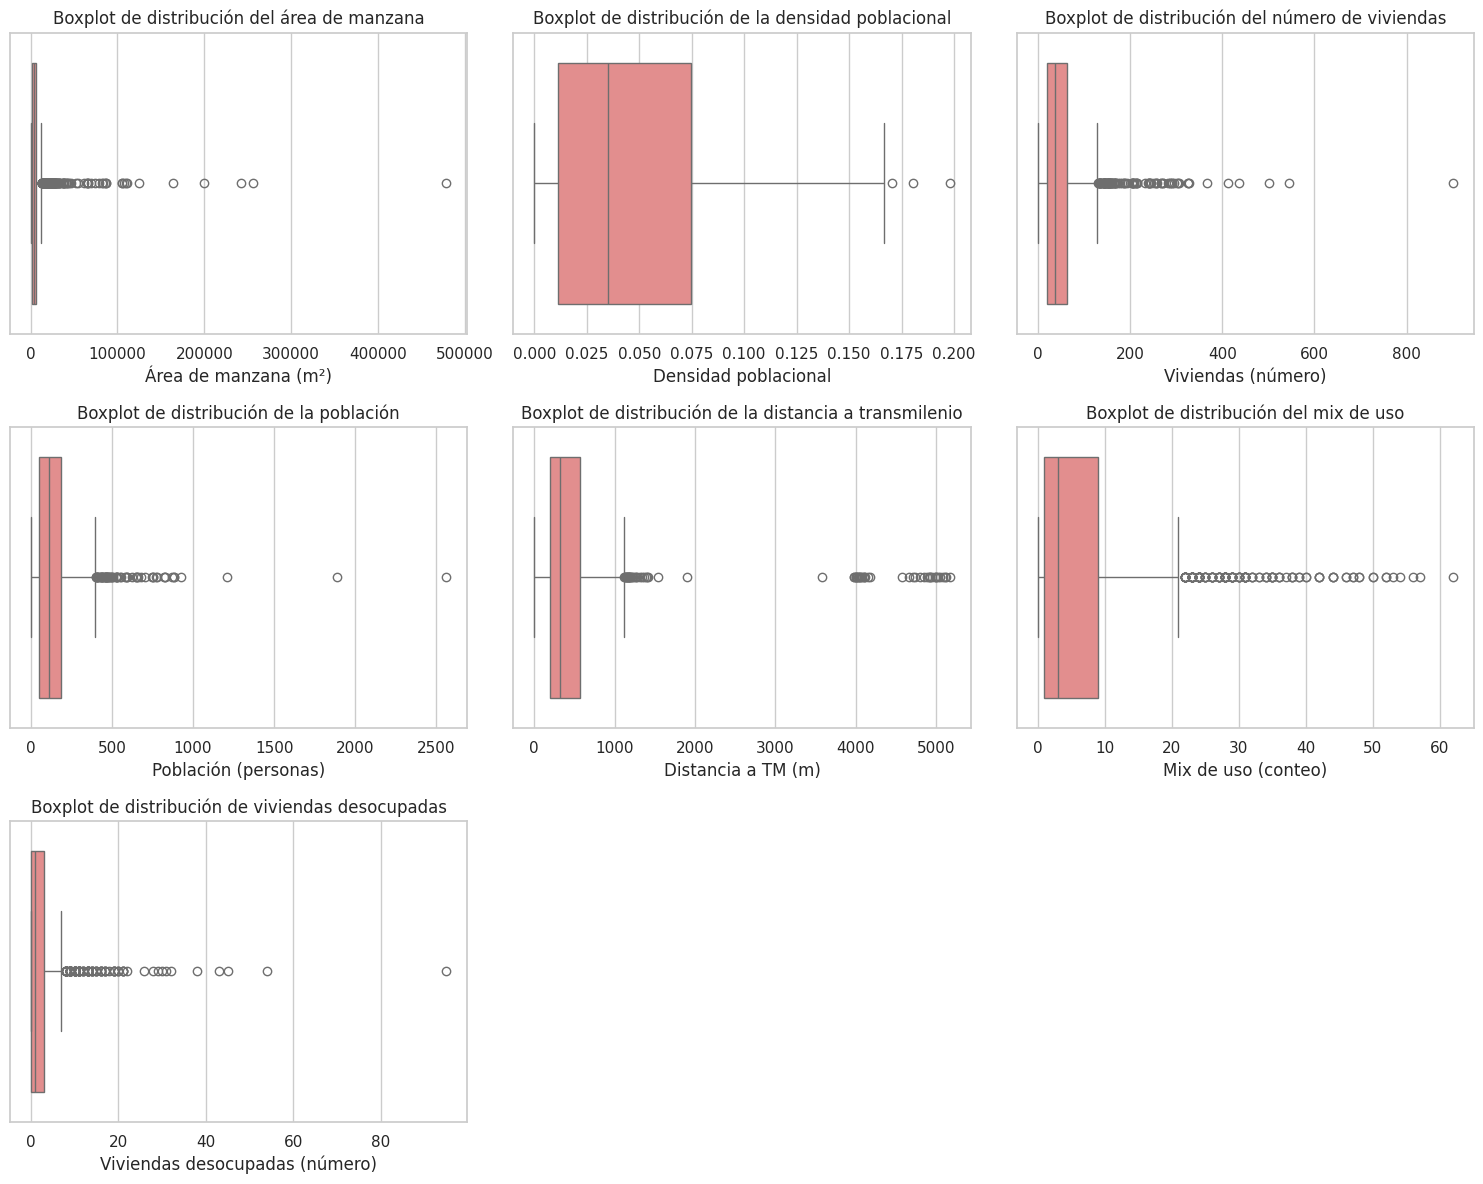

In [23]:
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for i, (var, titulo, xlabel) in enumerate(graficos):
    sns.boxplot(x=df_modelo[var], ax=axes[i], color="lightcoral")
    axes[i].set_title(f"Boxplot de {titulo.lower()}")
    axes[i].set_xlabel(xlabel)

for j in range(len(graficos), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

CORRELACION

## 8. Relación entre variables urbanas

Se calcula una matriz de correlación para identificar relaciones lineales entre variables y justificar la aplicación de PCA.

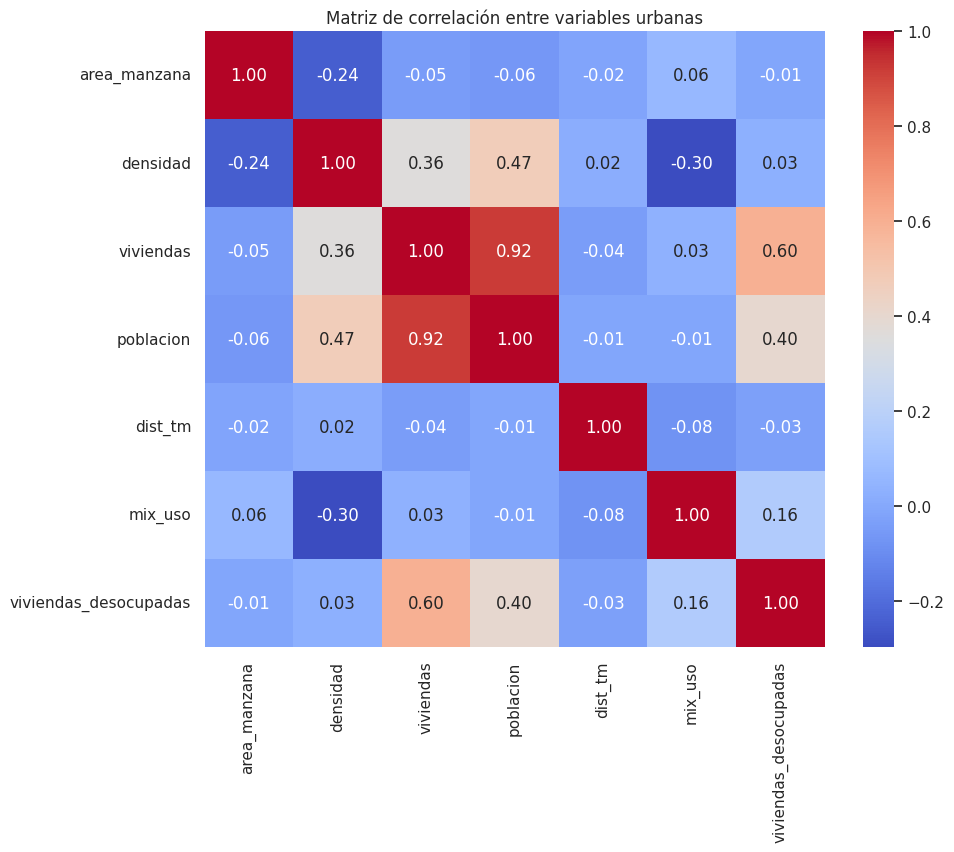

In [24]:
plt.figure(figsize=(10, 8))
sns.heatmap(df_modelo[variables].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matriz de correlación entre variables urbanas")
plt.show()

### Interpretación de la matriz de correlación

La matriz de correlación permite identificar la relación lineal entre las variables urbanas utilizadas en el análisis. Se observa una correlación alta entre `poblacion` y `viviendas`, lo cual sugiere que ambas variables capturan parcialmente una misma dimensión del sistema urbano asociada a la intensidad residencial.

Por su parte, `densidad` presenta correlaciones moderadas con `poblacion` y `viviendas`, lo que indica que resume parte de esta intensidad urbana pero incorpora además el efecto del tamaño de la manzana. En contraste, `dist_tm` muestra correlaciones bajas con el resto de variables, lo cual sugiere que representa una dimensión distinta del territorio asociada a accesibilidad.

La variable `mix_uso`, construida como la suma de unidades no residenciales con uso comercial e industrial, se interpreta como un proxy de actividad económica no residencial en la manzana. Sus bajas correlaciones con las variables residenciales sugieren que aporta información complementaria al modelo.

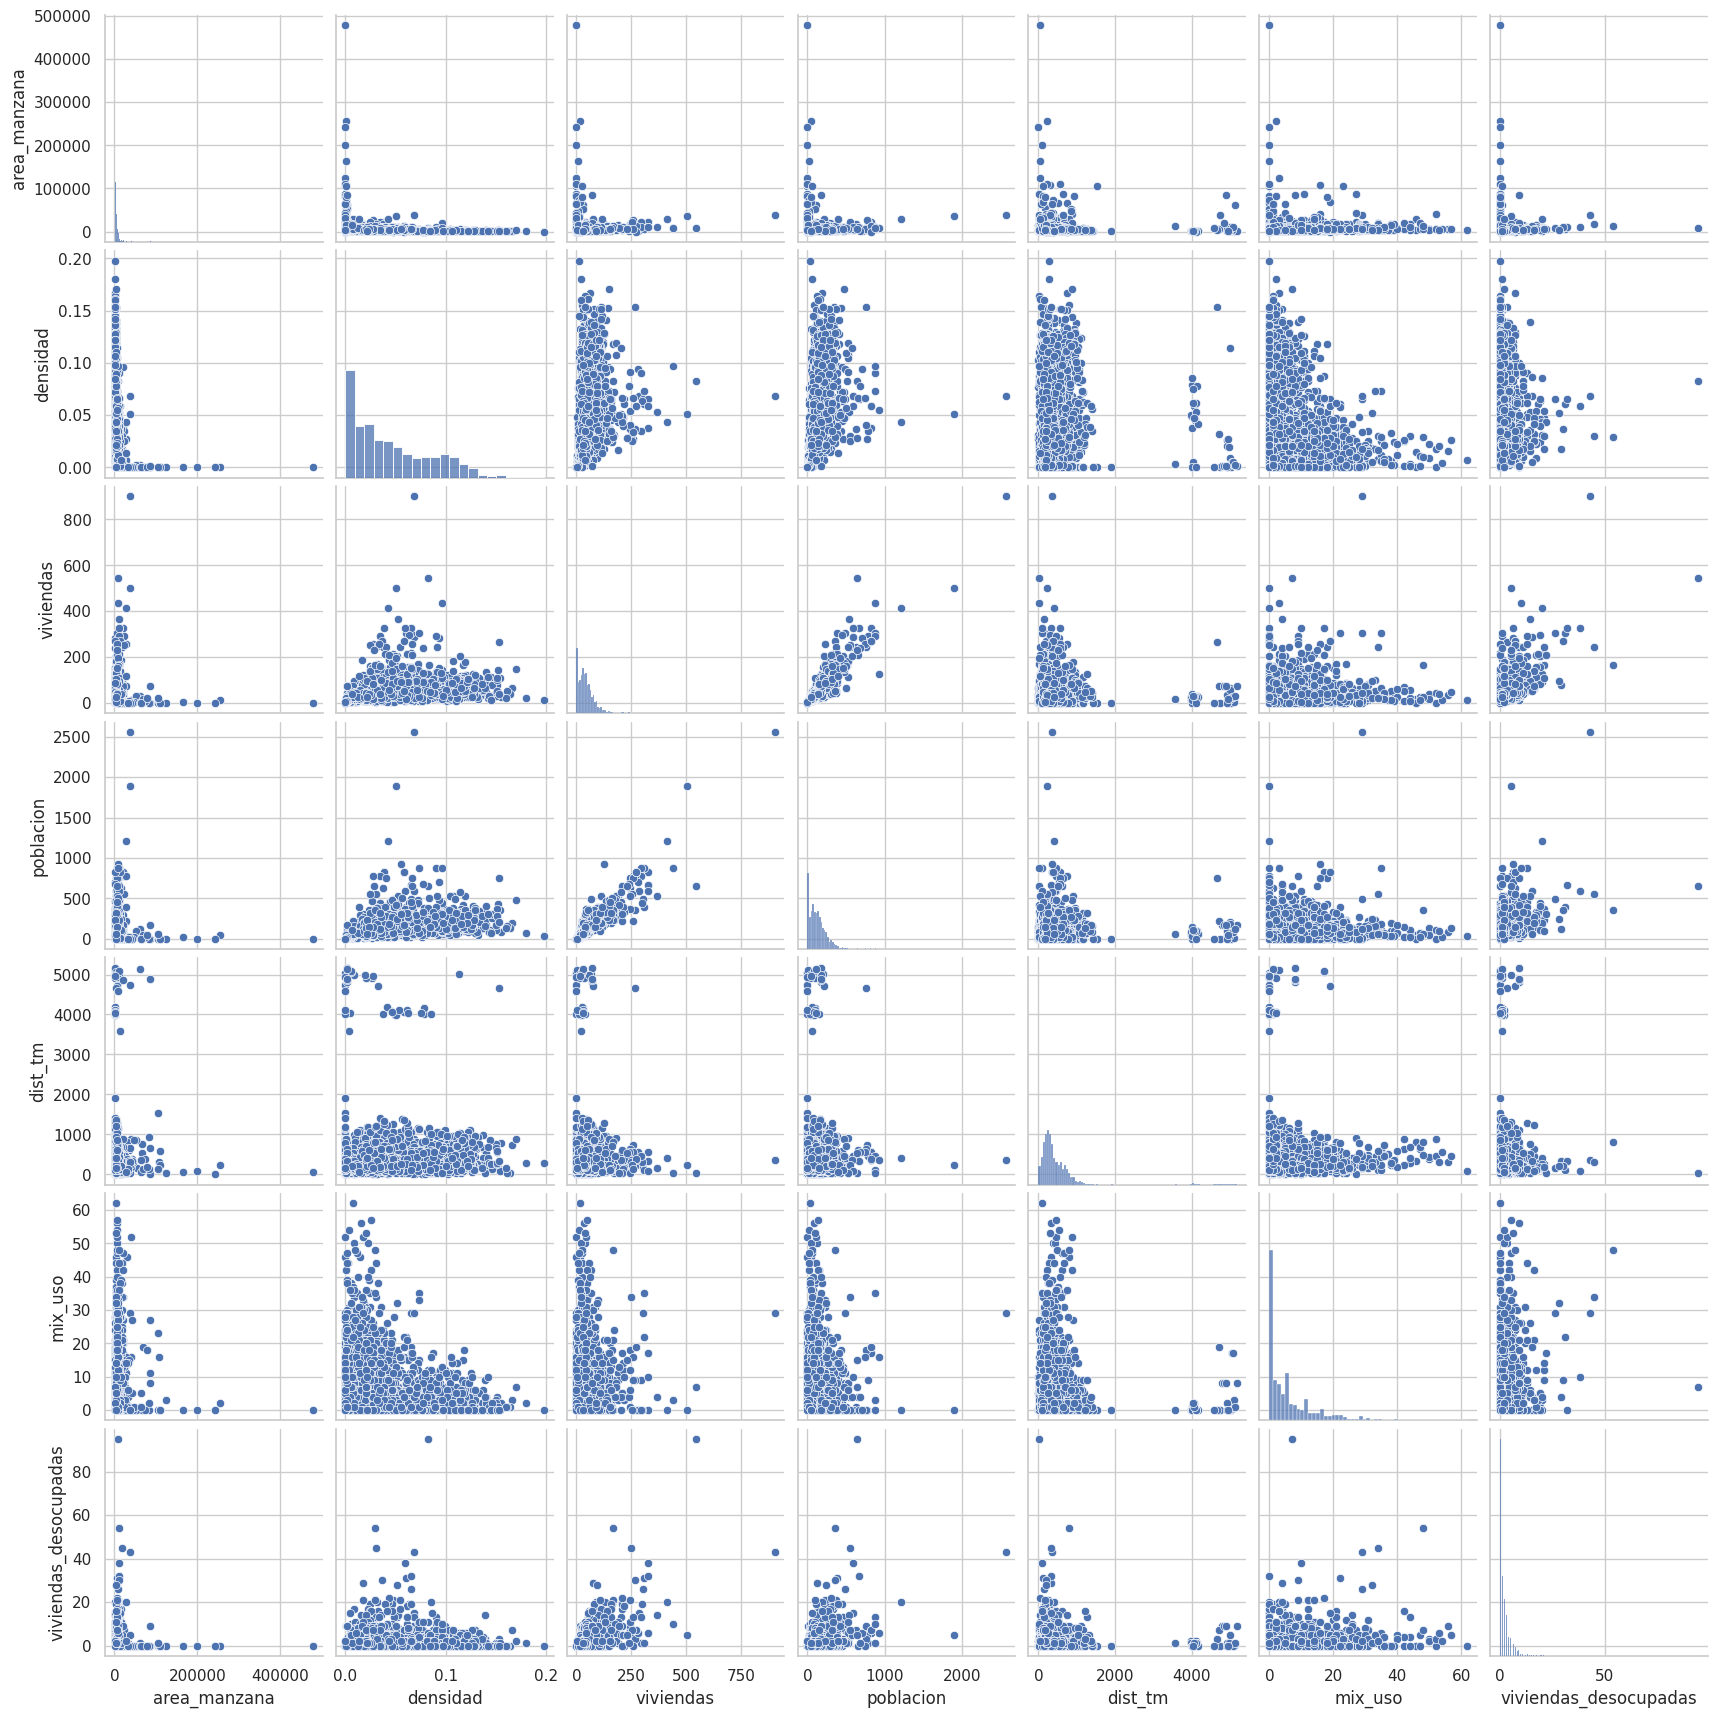

In [25]:
sns.pairplot(df_modelo[variables])
plt.show()

NORMALIZACION

## 9. Normalización de variables

Dado que las variables se encuentran en diferentes escalas y unidades (por ejemplo, metros cuadrados, personas, número de viviendas y distancias en metros), se aplica una normalización mediante StandardScaler para que ninguna variable domine el proceso de clustering.

In [27]:
X = df_modelo[variables]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

### Justificación de la normalización

Se aplicó una normalización mediante `StandardScaler` debido a que las variables utilizadas en el modelo presentan diferentes unidades y escalas de medición. Por ejemplo, `area_manzana` se expresa en metros cuadrados, `poblacion` en personas, `viviendas` en conteos, y `dist_tm` en metros.

Sin este proceso, variables con magnitudes numéricas más altas podrían dominar el cálculo de distancias en algoritmos como K-Means. La normalización permite que todas las variables contribuyan de manera comparable al análisis.

PCA

## 10. Análisis de Componentes Principales (PCA)

Se aplica PCA con el fin de reducir la dimensionalidad del conjunto de variables urbanas y capturar la mayor parte de la varianza del sistema territorial en un número reducido de componentes.

In [29]:
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

pca.explained_variance_ratio_

array([0.35866595, 0.20319057, 0.14204715, 0.13372592, 0.09461324,
       0.06103351, 0.00672366])

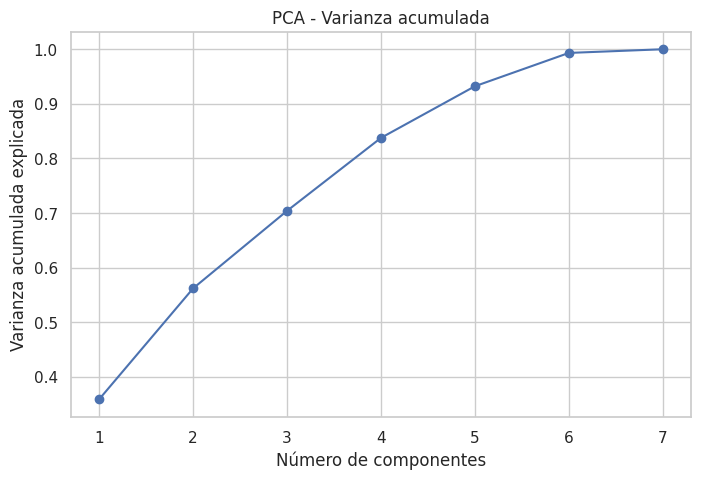

In [30]:
plt.figure(figsize=(8, 5))
plt.plot(
    range(1, len(pca.explained_variance_ratio_) + 1),
    pca.explained_variance_ratio_.cumsum(),
    marker="o"
)
plt.xlabel("Número de componentes")
plt.ylabel("Varianza acumulada explicada")
plt.title("PCA - Varianza acumulada")
plt.grid(True)
plt.show()

In [31]:
loadings = pd.DataFrame(
    pca.components_.T,
    columns=[f"PC{i+1}" for i in range(len(variables))],
    index=variables
)

loadings.round(3)

,PC1,PC2,PC3,PC4,PC5,PC6,PC7
area_manzana,-0.104,0.376,0.390,0.787,-0.187,0.203,0.006
densidad,0.352,-0.525,-0.102,0.088,-0.368,0.666,0.062
viviendas,0.602,0.129,0.054,0.057,-0.012,-0.291,0.728
poblacion,0.586,0.000,0.049,0.099,-0.248,-0.391,-0.656
dist_tm,-0.023,-0.191,0.902,-0.379,-0.080,0.004,0.017
mix_uso,-0.020,0.617,-0.110,-0.439,-0.611,0.199,0.019
viviendas_desocupadas,0.399,0.386,0.085,-0.151,0.623,0.489,-0.187


### Interpretación del PCA

El Análisis de Componentes Principales permite reducir la dimensionalidad del conjunto de variables urbanas, resumiendo la información en un número menor de componentes que concentran la mayor parte de la variabilidad del sistema.

Cada componente principal representa una combinación lineal de variables urbanas. La matriz de cargas permite identificar qué variables aportan más a cada componente y, por tanto, qué dimensiones estructuran el territorio analizado.

METODO DEL CODO

### Interpretación del PCA

El Análisis de Componentes Principales permite reducir la dimensionalidad del conjunto de variables urbanas, resumiendo la información en un número menor de componentes que concentran la mayor parte de la variabilidad del sistema.

Cada componente principal representa una combinación lineal de variables urbanas. La matriz de cargas permite identificar qué variables aportan más a cada componente y, por tanto, qué dimensiones estructuran el territorio analizado.

## 11. Método del codo

Se utiliza el método del codo para determinar el número adecuado de clusters en el algoritmo K-Means.

In [32]:
inertia = []

for k in range(1, 10):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

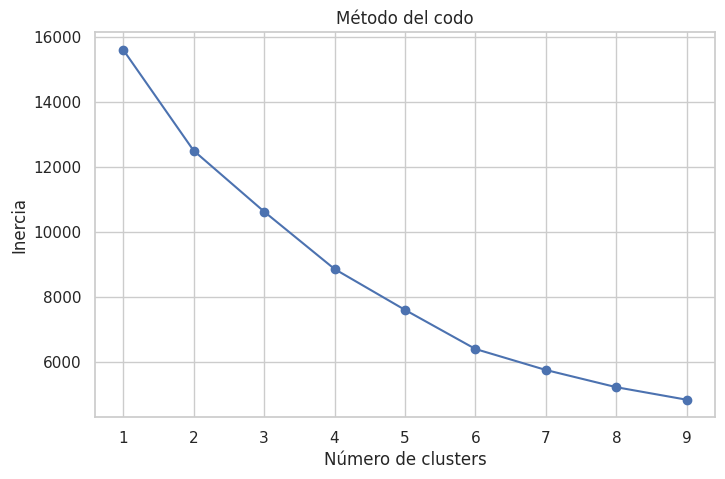

In [33]:
plt.figure(figsize=(8, 5))
plt.plot(range(1, 10), inertia, marker="o")
plt.xlabel("Número de clusters")
plt.ylabel("Inercia")
plt.title("Método del codo")
plt.grid(True)
plt.show()

KMEANS

## 12. Clustering con K-Means

Con base en el método del codo, se define el número de clusters y se agrupan las manzanas según similitud en sus características urbanas.

In [34]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df_modelo["cluster"] = kmeans.fit_predict(X_scaled)

In [35]:
df_modelo["cluster"].value_counts()

,count
cluster,
0,1201
2,954
1,73


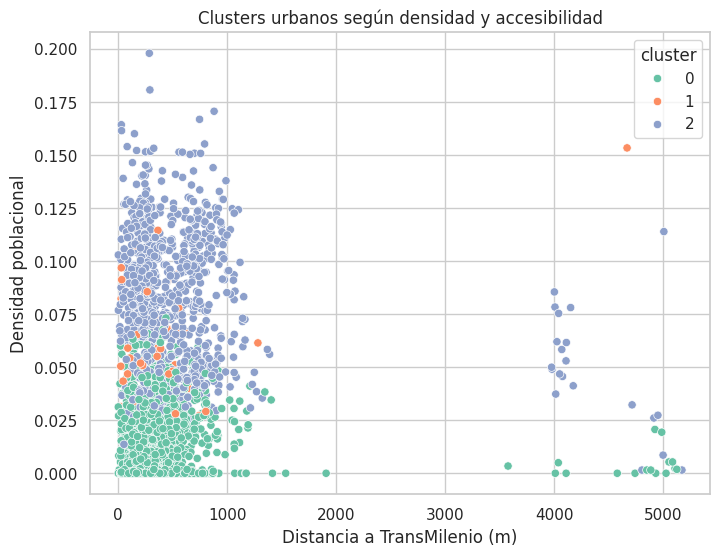

In [36]:
plt.figure(figsize=(8, 6))
sns.scatterplot(
    x=df_modelo["dist_tm"],
    y=df_modelo["densidad"],
    hue=df_modelo["cluster"],
    palette="Set2"
)
plt.title("Clusters urbanos según densidad y accesibilidad")
plt.xlabel("Distancia a TransMilenio (m)")
plt.ylabel("Densidad poblacional")
plt.show()

INTERPRETACION DE CLUSTERS

## 13. Interpretación de clusters

Los clusters identificados por K-Means representan tipologías urbanas de manzanas con características similares. A partir de los promedios por cluster, se interpretan como grupos con diferente potencial de renovación urbana.

In [37]:
df_modelo.groupby("cluster")[variables].mean().round(3)

,area_manzana,densidad,viviendas,poblacion,dist_tm,mix_uso,viviendas_desocupadas
cluster,,,,,,,
0,9101.506,0.016,24.482,63.689,411.284,8.869,1.479
1,9440.305,0.056,234.082,534.575,357.752,9.822,15.479
2,2867.105,0.081,63.647,195.904,527.243,3.037,1.832


In [38]:
mapa_prioridad = {
    1: "alta",
    0: "media",
    2: "baja"
}

df_modelo["prioridad"] = df_modelo["cluster"].map(mapa_prioridad)

In [40]:
df_modelo.groupby("prioridad")[variables].mean().round(3)

,area_manzana,densidad,viviendas,poblacion,dist_tm,mix_uso,viviendas_desocupadas
prioridad,,,,,,,
alta,9440.305,0.056,234.082,534.575,357.752,9.822,15.479
baja,2867.105,0.081,63.647,195.904,527.243,3.037,1.832
media,9101.506,0.016,24.482,63.689,411.284,8.869,1.479


In [41]:
df_modelo["prioridad"].value_counts()

,count
prioridad,
media,1201
baja,954
alta,73


In [42]:
df_modelo.groupby("prioridad")[variables].mean().round(3)

,area_manzana,densidad,viviendas,poblacion,dist_tm,mix_uso,viviendas_desocupadas
prioridad,,,,,,,
alta,9440.305,0.056,234.082,534.575,357.752,9.822,15.479
baja,2867.105,0.081,63.647,195.904,527.243,3.037,1.832
media,9101.506,0.016,24.482,63.689,411.284,8.869,1.479


In [44]:
df_modelo["score_renovacion"] = (
    df_modelo["densidad"] * 0.30 +
    df_modelo["mix_uso"] * 0.20 +
    (1 / (df_modelo["dist_tm"] + 1)) * 0.30 +
    df_modelo["viviendas_desocupadas"] * 0.20
)

In [45]:
df_modelo["score_renovacion"]

,score_renovacion
0,2.415952
1,0.604312
2,1.408618
3,4.611927
4,7.603021
...,...
3393,2.401786
3394,0.832666
3395,3.807442
3396,3.209784


In [47]:
df_modelo["score_renovacion"].head()

,score_renovacion
0,2.415952
1,0.604312
2,1.408618
3,4.611927
4,7.603021


In [48]:
df_modelo["score_renovacion"] = (
    df_modelo["densidad"] * 0.30 +
    df_modelo["mix_uso"] * 0.20 +
    (1 / (df_modelo["dist_tm"] + 1)) * 0.30 +
    df_modelo["viviendas_desocupadas"] * 0.20
)

In [49]:
df_modelo["score_renovacion"].describe()

,score_renovacion
count,2228.000000
mean,1.714103
std,2.018983
min,0.000060
25%,0.407420
50%,1.025725
75%,2.400594
max,20.435832


Clusters por actuación estratégica

In [50]:
pd.crosstab(df_modelo["actuacion_estrategica"], df_modelo["cluster"])

cluster,0,1,2
actuacion_estrategica,,,
20 de Julio,35,1,14
Borde Usme,16,1,21
Calle 72,100,0,24
Campin 7 de Agosto,100,1,2
Chapinero verde e inteligente,53,23,21
Chucua La Vaca,41,1,117
Ciudadela educativa y del cuidado,32,10,149
Distrito Aeroportuario Engativá,62,5,204
Distrito Aeroportuario Fontibón,163,9,257


In [51]:
tabla_clusters_ae = pd.crosstab(
    df_modelo["actuacion_estrategica"],
    df_modelo["cluster"],
    normalize="index"
)

tabla_clusters_ae.round(2)

cluster,0,1,2
actuacion_estrategica,,,
20 de Julio,0.70,0.02,0.28
Borde Usme,0.42,0.03,0.55
Calle 72,0.81,0.00,0.19
Campin 7 de Agosto,0.97,0.01,0.02
Chapinero verde e inteligente,0.55,0.24,0.22
Chucua La Vaca,0.26,0.01,0.74
Ciudadela educativa y del cuidado,0.17,0.05,0.78
Distrito Aeroportuario Engativá,0.23,0.02,0.75
Distrito Aeroportuario Fontibón,0.38,0.02,0.60


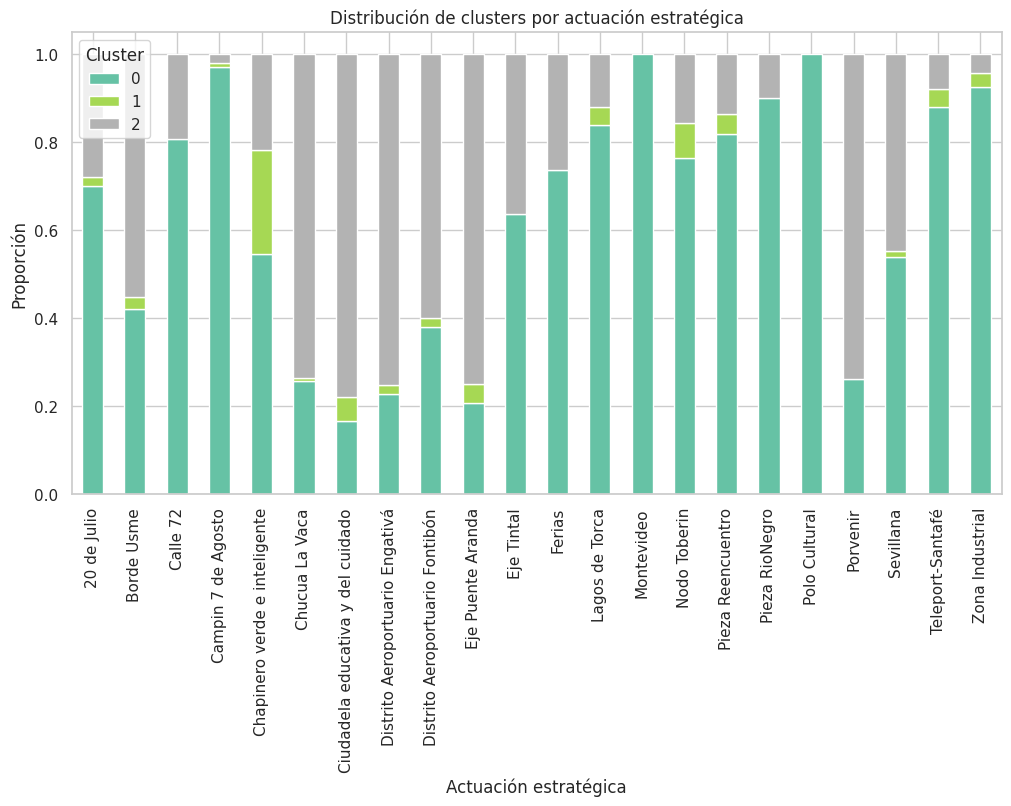

In [52]:
tabla_clusters_ae.plot(
    kind="bar",
    stacked=True,
    figsize=(12,6),
    colormap="Set2"
)

plt.title("Distribución de clusters por actuación estratégica")
plt.xlabel("Actuación estratégica")
plt.ylabel("Proporción")
plt.legend(title="Cluster")
plt.show()

Prioridad por actuación estratégica

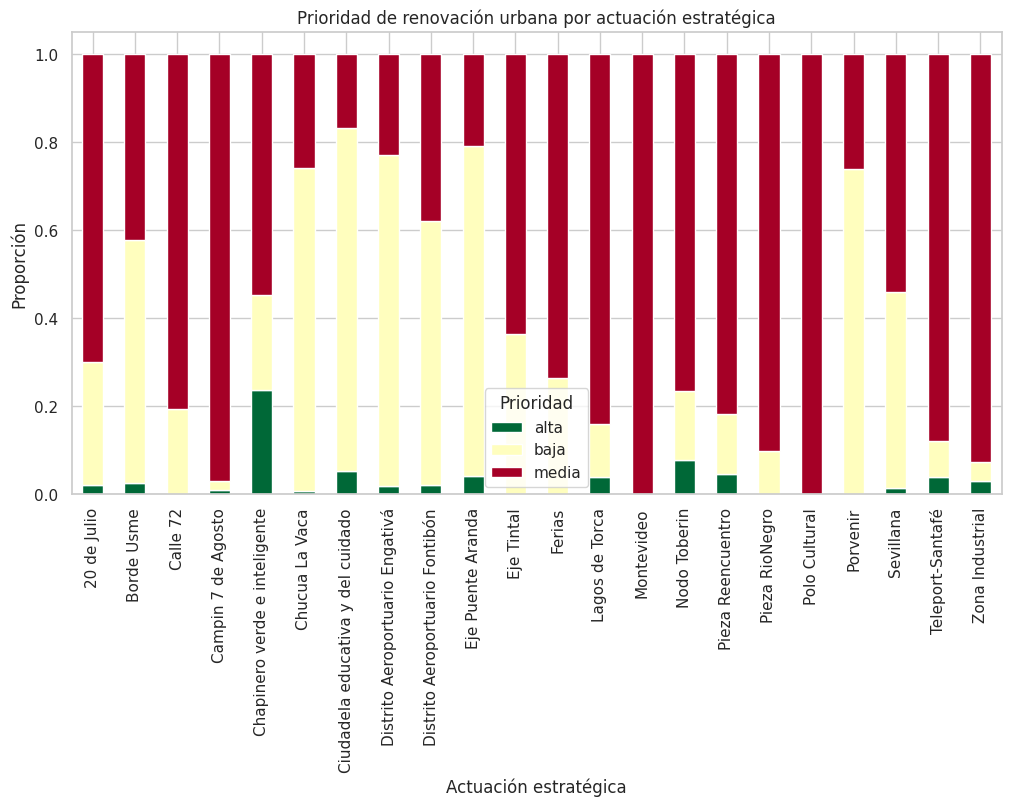

In [55]:
tabla_prioridad_ae.plot(
    kind="bar",
    stacked=True,
    figsize=(12,6),
    colormap="RdYlGn_r"
)

plt.title("Prioridad de renovación urbana por actuación estratégica")
plt.xlabel("Actuación estratégica")
plt.ylabel("Proporción")
plt.legend(title="Prioridad")
plt.show()

In [54]:
tabla_prioridad_ae = pd.crosstab(
    df_modelo["actuacion_estrategica"],
    df_modelo["prioridad"],
    normalize="index"
)

tabla_prioridad_ae.round(2)

prioridad,alta,baja,media
actuacion_estrategica,,,
20 de Julio,0.02,0.28,0.70
Borde Usme,0.03,0.55,0.42
Calle 72,0.00,0.19,0.81
Campin 7 de Agosto,0.01,0.02,0.97
Chapinero verde e inteligente,0.24,0.22,0.55
Chucua La Vaca,0.01,0.74,0.26
Ciudadela educativa y del cuidado,0.05,0.78,0.17
Distrito Aeroportuario Engativá,0.02,0.75,0.23
Distrito Aeroportuario Fontibón,0.02,0.60,0.38


In [56]:
df_modelo.to_excel("resultado_clusters.xlsx", index=False)